# Tutorial: useful operations when working with solute datasets

In this Notebook we will be going through the main operations that may be useful when processing and displaying a solute dataset. We will practice the following operations:

- data selection (select columns, filter by row values)
- dataset visualization, using `seaborn`
- reshaping: 
    - make the table longer (using the `pd.melt()` function) 
    - make the table wider (using the `pd.pivot()` function or `pivot()` method)
- grouping and group statistics (e.g. compute long-term monthly values)
- (joining data from multiple datasets is something we will do later in the course)

## The data

We will use the [Plynlimon research catchment hydrochemistry](https://doi.org/10.5285/44095e17-43b0-45d4-a781-aab4f72da025) published by Neal, Kirchner, and Reynolds (2013) and previously described in Neal et al. ([2011](https://doi.org/10.1002/hyp.8191)). The data are part of a large data collection from the [Plynlimon experimental watersheds](https://www.ceh.ac.uk/our-science/monitoring-sites/plynlimon-research-catchments) (UK), which have been studied for years and have led to tens of scientific papers. 

The hydrochemistry data files include:

- **supporting-documents**, with several metadata files describing the sites, the field and analytical methods, and with a full description of the measured variables. 

- **data/PlynlimonResearchCatchmentHydrochemistryData.csv**, which is a data table with the measured hydrochemistry at the different sites collected approximately at weekly frequency. The data table has 15661 rows and 143 columns. All column names with "RDA" include the raw data version of the measurements.

In [1]:
# load the main packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

## Overview of the data

In [2]:
# Import the data into a Pandas DataFrame
data_path = os.path.join(   # indicate where the data is to be found
    "weekly_hydrochem",
    "data",
    "PlynlimonResearchCatchmentHydrochemistryData.csv"
    )
df = pd.read_csv(data_path)

# Since the variable "date_time" is not automatically recognised as 
# date, let's force it to be a pd datetime object 
df["date_time"] = pd.to_datetime(df["date_time"])

In [3]:
# Look at the dataset size and display some entries
nrow,ncol = df.shape  # get number of rows and columns
print(f'The sample dataset has {nrow} rows and {ncol} columns')
df.sample(3)  # display a small sample of the data

The sample dataset has 15661 rows and 143 columns


,SAMPLE,LOCATION,SITE NAME,date_time,Volume-weighted mean sampling time,Date,Yr,Month,Day,Time,...,Stream flow (Cumecs) RDA,Rainfall (mm) RDA,Cloud catch g RDA,Ground Water m RDA,Throughfall mm RDA,Temperature Deg C RDA,Time RDA,NOTES,type,DESCRIPTION
871,67274.0,A,Lower Hore,1999-02-02 14:30:00,1999/02/02 14:30,1999/02/02,1999,2,2,2:30 PM,...,0.095161,NaN,NaN,NaN,NaN,6.1,2:30:00 PM,NaN,stream,Main Hore stream channel above lower flume
2346,72498.0,AD,Tanllwyth Bridge,2008-07-22 15:30:00,2008/07/22 15:30,2008/07/22,2008,7,22,3:30 PM,...,0.025400,NaN,NaN,NaN,NaN,16.0,0.645833333,NaN,stream,Main Tanllwyth stream channel above borehole T...
7902,15600.0,D,Upper Hore,1985-08-20 09:43:00,1985/08/20 09:43,1985/08/20,1985,8,20,9:43 AM,...,NaN,NaN,NaN,NaN,NaN,9.9,9:43:00 AM,NaN,stream,Main Hore stream channel above upper flume


### Shape of the data frame

The basic question here is: which information is in the rows and which information is in the columns? 

The variables (columns) in this table can be grouped as: 
- **location**, with equivalent variables "LOCATION" and "SITE NAME"
- **date**, reported in variables like "date_time", "Date", "Yr" etc
- **measurements**, with a lot of chemical measurements, including their raw values, and a few hydrologic measurements (flow at the time of sampling)

Each observation (row) is a *combination of multiple* measurements at *one* time and *one* location.

## Select columns and filter by row values

It can be very convenient to create a new dataset for each analysis/visualization. Based on the goal of the analysis, the new dataframe may need a different shape.

### Prepare a new dataframe for displaying multiple elements at multiple locations over time

To achieve this, we need to 
- filter the time and locations of interest
- select the variables that we are interested in (location, date and measurements)

Create a new dataframe `df1` which is a subset of the original dataframe

In [4]:
# Make a selection of variables and sites
var_selection = [
    "SITE NAME",  # for the location
    "date_time",  # for the time
    "Cl mg/l",   # element of interest
    "Na mg/l",  # element of interest
    "water flux mm/hr",  # element of interest
    ]  # selection of variables

# Create a boolean index to filter by location and time
q = (
    (df["SITE NAME"].isin(["Lower Hafren","Upper Hafren"])) &  # select 2 sites
    (df["date_time"] >= '1995-01-01') & (df["date_time"] < '1995-03-01')  # select a temporal interval
)

# Produce the new dataframe (subset using the loc method)
df1 = df.loc[q,var_selection]
df1  # show the dataframe

,SITE NAME,date_time,Cl mg/l,Na mg/l,water flux mm/hr
3770,Lower Hafren,1995-01-03 10:25:00,6.5,3.98,0.168000
3771,Lower Hafren,1995-01-10 09:30:00,7.5,4.49,0.428000
3772,Lower Hafren,1995-01-17 09:18:00,6.9,4.18,0.284000
3773,Lower Hafren,1995-01-24 09:30:00,8.7,4.54,0.336000
3774,Lower Hafren,1995-01-31 10:00:00,7.3,3.85,0.576000
3775,Lower Hafren,1995-02-07 10:10:00,6.7,4.11,0.196000
3776,Lower Hafren,1995-02-14 09:15:00,6.4,3.75,0.528000
3777,Lower Hafren,1995-02-21 09:45:00,7.7,3.98,0.660000
3778,Lower Hafren,1995-02-28 09:15:00,7.1,4.12,0.280000
9742,Upper Hafren,1995-01-03 11:35:00,5.4,3.44,0.195796


## Display the dataframe using seaborn

In its essence, a plot is the mapping of data into something that can be visually recognized. Besides the obvious mapping of 2 variables into the x and y axis of a plot, we can map data into other *aesthetics*, such as the color, the size and type of markers etc.

Here we see examples of:
- `sns.lineplot` ([documentation](https://seaborn.pydata.org/generated/seaborn.lineplot.html))
- `sns.scatterplot` ([documentation](https://seaborn.pydata.org/generated/seaborn.scatterplot.html))
- `sns.boxplot` ([documentation](https://seaborn.pydata.org/generated/seaborn.boxplot.html))
- `sns.stripplot` ([documentation](https://seaborn.pydata.org/generated/seaborn.stripplot.html))

Many more examples are in the [seaborn gallery](https://seaborn.pydata.org/examples/index.html#)

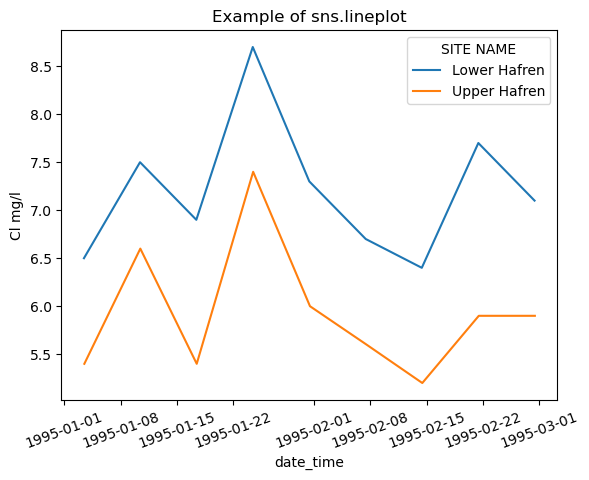

In [5]:
# Do a lineplot to map 3 variables into the main aesthetics (x axis, y axis and color)
g = sns.lineplot(
    data=df1, 
    x="date_time", 
    y="Cl mg/l", 
    hue="SITE NAME"
    )
plt.title("Example of sns.lineplot")
plt.xticks(rotation=20)  # to avoid overlapping of the labels
plt.show()

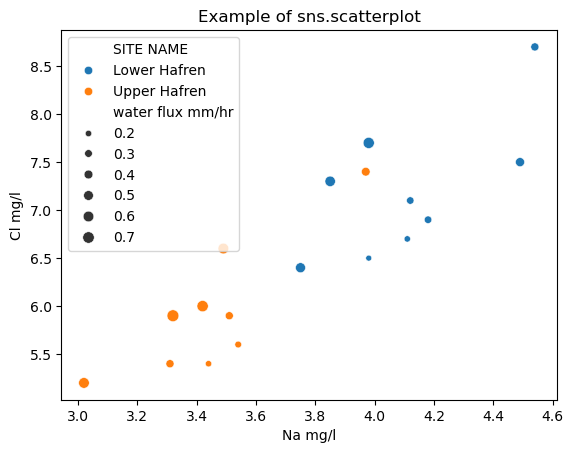

In [6]:
# Do a scatterplot to map 4 variables into the main aesthetics (x axis, y axis, 
# color, size)
g = sns.scatterplot(
    data=df1, 
    x="Na mg/l", 
    y="Cl mg/l", 
    hue="SITE NAME", 
    size="water flux mm/hr"
    )
plt.title("Example of sns.scatterplot")
plt.show()

By exploring the above plot we can already draw some early conclusions about the dataset `df1`:
- there is a strong linear correlation between the variables Cl and Na
- the Lower Hafren site has higher concentration for both solutes
- at high flows the linear relationship seems to be a bit steeper (because the larger dots in the plot are generally higher than the smaller plots)

Let's now display the distribution of Na values separately by month, using a box plot and a stripplot

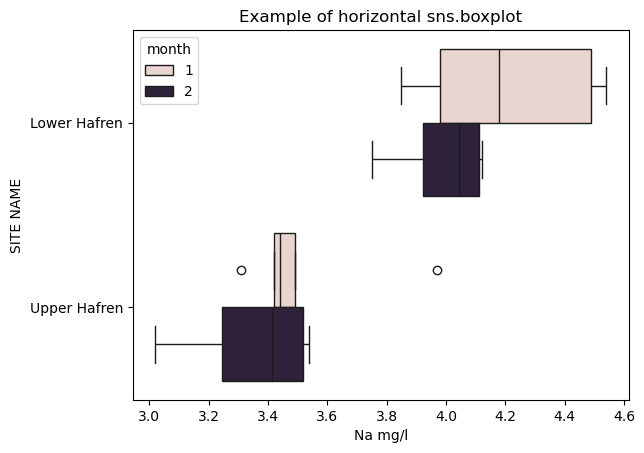

In [7]:
# Add a variable "month", with the month of the measurement
df1["month"] = df1["date_time"].dt.month # use the dt.month attribute

# Make the boxplot
g = sns.boxplot(
    data = df1, 
    x = "Na mg/l", 
    y = "SITE NAME",
    hue = "month", 
    )
plt.title("Example of horizontal sns.boxplot")
plt.show()

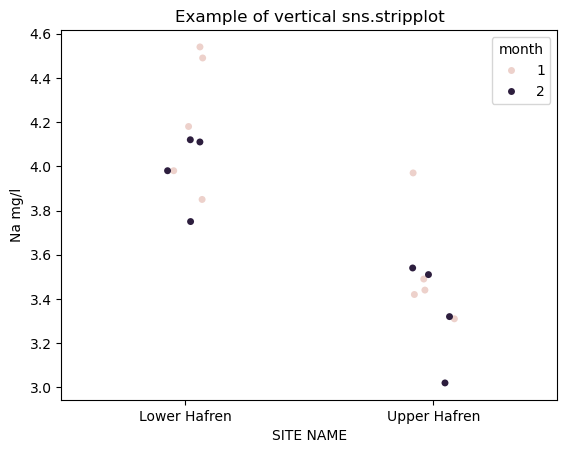

In [8]:
# Make the stripplot
g2 = sns.stripplot(
    data = df1, 
    y = "Na mg/l", 
    x = "SITE NAME", 
    hue = "month",
    )
plt.title("Example of vertical sns.stripplot")
plt.show()

In [9]:
# Remove a variable
df1 = df1.drop("month",axis=1)

## Reshape the dataset

The main point here is to make the dataset **longer** by stacking (or 'pivoting') multiple variables into a single column, or making it **wider** by un-stacking (or 'un-pivoting') variables from a single column to multiple columns.

Longer tables are very important for automatic plotting and for group operations (see below)

We will start from the same table as above, and reshape it to make it wider or longer

In [10]:
# Round the date to the day, for simplicity
df1["date_time"] = df1["date_time"].dt.round('d')

# Print the dataframe size and show it
print(f'Dataframe shape: {df1.shape}')
df1

Dataframe shape: (18, 5)


,SITE NAME,date_time,Cl mg/l,Na mg/l,water flux mm/hr
3770,Lower Hafren,1995-01-03,6.5,3.98,0.168000
3771,Lower Hafren,1995-01-10,7.5,4.49,0.428000
3772,Lower Hafren,1995-01-17,6.9,4.18,0.284000
3773,Lower Hafren,1995-01-24,8.7,4.54,0.336000
3774,Lower Hafren,1995-01-31,7.3,3.85,0.576000
3775,Lower Hafren,1995-02-07,6.7,4.11,0.196000
3776,Lower Hafren,1995-02-14,6.4,3.75,0.528000
3777,Lower Hafren,1995-02-21,7.7,3.98,0.660000
3778,Lower Hafren,1995-02-28,7.1,4.12,0.280000
9742,Upper Hafren,1995-01-03,5.4,3.44,0.195796


### Make the dataframe longer

There are many wayt to do this, but the easiest is to use the `pd.melt()` function. We will make the dataset longer by stacking (melting) the three variables `Cl mg/l`, `Na mg/l` and `water flux mm/hr` into a single variable.

In [11]:
# Make the table longer through the pd.melt() function
df1_long = pd.melt(
    df1,
    id_vars = ["SITE NAME","date_time"],  # these will be kepth but not pivoted
    value_vars = ['Cl mg/l', 'Na mg/l', 'water flux mm/hr']  # these will be pivoted
    )

# Print the dataframe size and show it
print(f'Dataframe shape: {df1_long.shape}')
df1_long

Dataframe shape: (54, 4)


,SITE NAME,date_time,variable,value
0,Lower Hafren,1995-01-03,Cl mg/l,6.500000
1,Lower Hafren,1995-01-10,Cl mg/l,7.500000
2,Lower Hafren,1995-01-17,Cl mg/l,6.900000
3,Lower Hafren,1995-01-24,Cl mg/l,8.700000
4,Lower Hafren,1995-01-31,Cl mg/l,7.300000
5,Lower Hafren,1995-02-07,Cl mg/l,6.700000
6,Lower Hafren,1995-02-14,Cl mg/l,6.400000
7,Lower Hafren,1995-02-21,Cl mg/l,7.700000
8,Lower Hafren,1995-02-28,Cl mg/l,7.100000
9,Upper Hafren,1995-01-03,Cl mg/l,5.400000


Compared to the original `df1` table, now each row corresponds to *one* measurements (rather than a combination of measurements) at *one* time and *one* location. Note that the total number of entries in the dataframe has more than doubled (from 18\*5=90 to 54\*4=216). This is because many entries like the variable name are now repeated multiple times.

### Make the dataframe wider

There are many ways to do this, but the easiest is to use the `pivot()` method.

We will make the dataset wider by pivoting the month variable. For each measurement, we will have a separate column for measurements carried out at the two different stations

In [12]:
# Make the table wider through the pivot method
df1_wide = df1.pivot(
    index = ["date_time"],  # these will be kepth but not pivoted
    columns = "SITE NAME",
    values = ['Cl mg/l', 'Na mg/l', 'water flux mm/hr']
)
df1_wide.columns = list(map(' '.join, df1_wide.columns.values))  # to get rid of the multi-index
df1_wide = df1_wide.reset_index()

# Print the dataframe size and show it
print(f'Dataframe shape: {df1_wide.shape}')
df1_wide

Dataframe shape: (11, 7)


,date_time,Cl mg/l Lower Hafren,Cl mg/l Upper Hafren,Na mg/l Lower Hafren,Na mg/l Upper Hafren,water flux mm/hr Lower Hafren,water flux mm/hr Upper Hafren
0,1995-01-03,6.5,5.4,3.98,3.44,0.168,0.195796
1,1995-01-10,7.5,6.6,4.49,3.49,0.428,0.611089
2,1995-01-17,6.9,5.4,4.18,3.31,0.284,0.338634
3,1995-01-24,8.7,7.4,4.54,3.97,0.336,0.389972
4,1995-01-31,7.3,NaN,3.85,NaN,0.576,NaN
5,1995-02-01,NaN,6.0,NaN,3.42,NaN,0.678276
6,1995-02-07,6.7,NaN,4.11,NaN,0.196,NaN
7,1995-02-08,NaN,5.6,NaN,3.54,NaN,0.225500
8,1995-02-14,6.4,5.2,3.75,3.02,0.528,0.603777
9,1995-02-21,7.7,5.9,3.98,3.32,0.660,0.749436


As you can see, now the table is wider and shorter. The total number of entries is 11\*7=77, which is smaller than the original dataset because no entries are repeated multiple times. The price to pay, however, is that useful information is now hidden in the column names rather than being readily available for processing. In this wider table, each row corresponds to a *combination of* measurements at *one* time at *each* location.

Note that some `NaN` appeared corresponding to dates in which measurements were carried out at one site but not at the other one (because measurements were sometimes not carried out in the same exact day, but over two consecutive days).

## Grouped variables

A very useful feature of data tables, especially long-format tables, is the ability to make operations separately for each group. See [here](https://pandas.pydata.org/docs/user_guide/groupby.html) for more insight.

Let's start from the longer table `df1_long` and compute some statistics of the measurements **separately for each location**. This will be done automatically, by specifying which variables define the groups.

In [13]:
# Compute the mean for each variable at each site
df1_long_agg = df1_long.groupby(by=["SITE NAME","variable"]).mean().reset_index()
df1_long_agg

,SITE NAME,variable,date_time,value
0,Lower Hafren,Cl mg/l,1995-01-31 00:00:00,7.200000
1,Lower Hafren,Na mg/l,1995-01-31 00:00:00,4.111111
2,Lower Hafren,water flux mm/hr,1995-01-31 00:00:00,0.384000
3,Upper Hafren,Cl mg/l,1995-01-31 05:20:00,5.933333
4,Upper Hafren,Na mg/l,1995-01-31 05:20:00,3.446667
5,Upper Hafren,water flux mm/hr,1995-01-31 05:20:00,0.458100


Sometimes it can be useful to reshape the data back to a wide format

In [14]:
# Make the aggregated table wider
df1_agg_wide = df1_long_agg.pivot(
    index = "SITE NAME",
    columns = "variable",
    values = ["value"]
)
df1_agg_wide.columns = list(map(' '.join, df1_agg_wide.columns.values))  # to get rid of the multi-index
df1_agg_wide = df1_agg_wide.reset_index()
df1_agg_wide

,SITE NAME,value Cl mg/l,value Na mg/l,value water flux mm/hr
0,Lower Hafren,7.200000,4.111111,0.3840
1,Upper Hafren,5.933333,3.446667,0.4581


In [15]:
# More advanced grouping (creates multi-index, which we need to remove)
aggr_functions = ["count","mean","std"]
df1_long_agg = (
    df1_long
    .drop("date_time",axis=1)  # remove the date, as it cannot be aggregated
    .groupby(by=["SITE NAME","variable"])  # choose grouping variables
    .aggregate(aggr_functions)  # define which aggregations will be done
    )

# Remove the multi-index
df1_long_agg.columns = list(map('_'.join, df1_long_agg.columns.values))  # remove the multi-index from the columns
df1_long_agg = df1_long_agg.reset_index()
df1_long_agg

,SITE NAME,variable,value_count,value_mean,value_std
0,Lower Hafren,Cl mg/l,9,7.200000,0.714143
1,Lower Hafren,Na mg/l,9,4.111111,0.265822
2,Lower Hafren,water flux mm/hr,9,0.384000,0.173505
3,Upper Hafren,Cl mg/l,9,5.933333,0.691014
4,Upper Hafren,Na mg/l,9,3.446667,0.251496
5,Upper Hafren,water flux mm/hr,9,0.458100,0.204971
